## Aurora Prediction for ERA5

This example is modified from the notebook published by Microsoft, but utilizing computing resource of NCCS Discover cluster:


- [example_era5](https://github.com/microsoft/aurora/blob/main/docs/example_era5.ipynb)




In [5]:
import sys
sys.path.append("../qefm/models/src/FMAurora")
sys.path.append("/explore/nobackup/people/jli30/tmp")

In [9]:
from pathlib import Path
import xarray as xr
import torch

### Load example data from Discover

In [12]:
yyyy = 2024
mm = 12
dd = 2


In [13]:
t_stamp = f"{yyyy}-{mm:02d}-{dd:02d}"

In [14]:
## Data Path for Discover 
# data_path = Path("/discover/nobackup/projects/QEFM/data/FMAurora")

## Data Path for ADAPT
data_path = Path("/explore/nobackup/projects/ilab/data/qefm/aurora/sample_data")
static_file = data_path / "static.nc"
surf_file = data_path / f"{t_stamp}-surface-level.nc"
atmos_file = data_path / f"{t_stamp}-atmospheric.nc"

In [15]:
#import xarray as xr
#from aurora import Batch, Metadata
static_vars_ds = xr.open_dataset(static_file)
surf_vars_ds = xr.open_dataset(surf_file)
atmos_vars_ds = xr.open_dataset(atmos_file)

### Preparing a Batch
To convert xr.dataset to an aurora.Batch, which is what the model requires.

In [17]:
import torch
from aurora import Batch, Metadata

In [18]:
batch = Batch(
    surf_vars={
        # First select the first two time points: 00:00 and 06:00. Afterwards, `[None]`
        # inserts a batch dimension of size one.
        "2t": torch.from_numpy(surf_vars_ds["t2m"].values[:2][None]),
        "10u": torch.from_numpy(surf_vars_ds["u10"].values[:2][None]),
        "10v": torch.from_numpy(surf_vars_ds["v10"].values[:2][None]),
        "msl": torch.from_numpy(surf_vars_ds["msl"].values[:2][None]),
    },
    static_vars={
        # The static variables are constant, so we just get them for the first time.
        "z": torch.from_numpy(static_vars_ds["z"].values[0]),
        "slt": torch.from_numpy(static_vars_ds["slt"].values[0]),
        "lsm": torch.from_numpy(static_vars_ds["lsm"].values[0]),
    },
    atmos_vars={
        "t": torch.from_numpy(atmos_vars_ds["t"].values[:2][None]),
        "u": torch.from_numpy(atmos_vars_ds["u"].values[:2][None]),
        "v": torch.from_numpy(atmos_vars_ds["v"].values[:2][None]),
        "q": torch.from_numpy(atmos_vars_ds["q"].values[:2][None]),
        "z": torch.from_numpy(atmos_vars_ds["z"].values[:2][None]),
    },
    metadata=Metadata(
        lat=torch.from_numpy(surf_vars_ds.latitude.values),
        lon=torch.from_numpy(surf_vars_ds.longitude.values),
        # Converting to `datetime64[s]` ensures that the output of `tolist()` gives
        # `datetime.datetime`s. Note that this needs to be a tuple of length one:
        # one value for every batch element. Select element 1, corresponding to time
        # 06:00.
        time=(surf_vars_ds.valid_time.values.astype("datetime64[s]").tolist()[1],),
        atmos_levels=tuple(int(level) for level in atmos_vars_ds.pressure_level.values),
    ),
)

### Loading and Running the Model

In [20]:
from aurora import Aurora, rollout

In [21]:
model = Aurora(use_lora=False)  # The pretrained version does not use LoRA.

In [22]:
# On Discover
#ckpt_path = "/discover/nobackup/projects/QEFM/qefm-core/qefm/models/checkpoints/aurora/aurora-0.25-pretrained.ckpt"
# On ADAPT
ckpt_path = "/explore/nobackup/projects/ilab/projects/QEFM/qefm-core/qefm/models/checkpoints/aurora/aurora-0.25-pretrained.ckpt"
model.load_checkpoint_local(ckpt_path)

In [23]:
model.eval()
model = model.to("cuda")

In [24]:
with torch.inference_mode():
    preds = [pred.to("cpu") for pred in rollout(model, batch, steps=2)]

model = model.to("cpu")

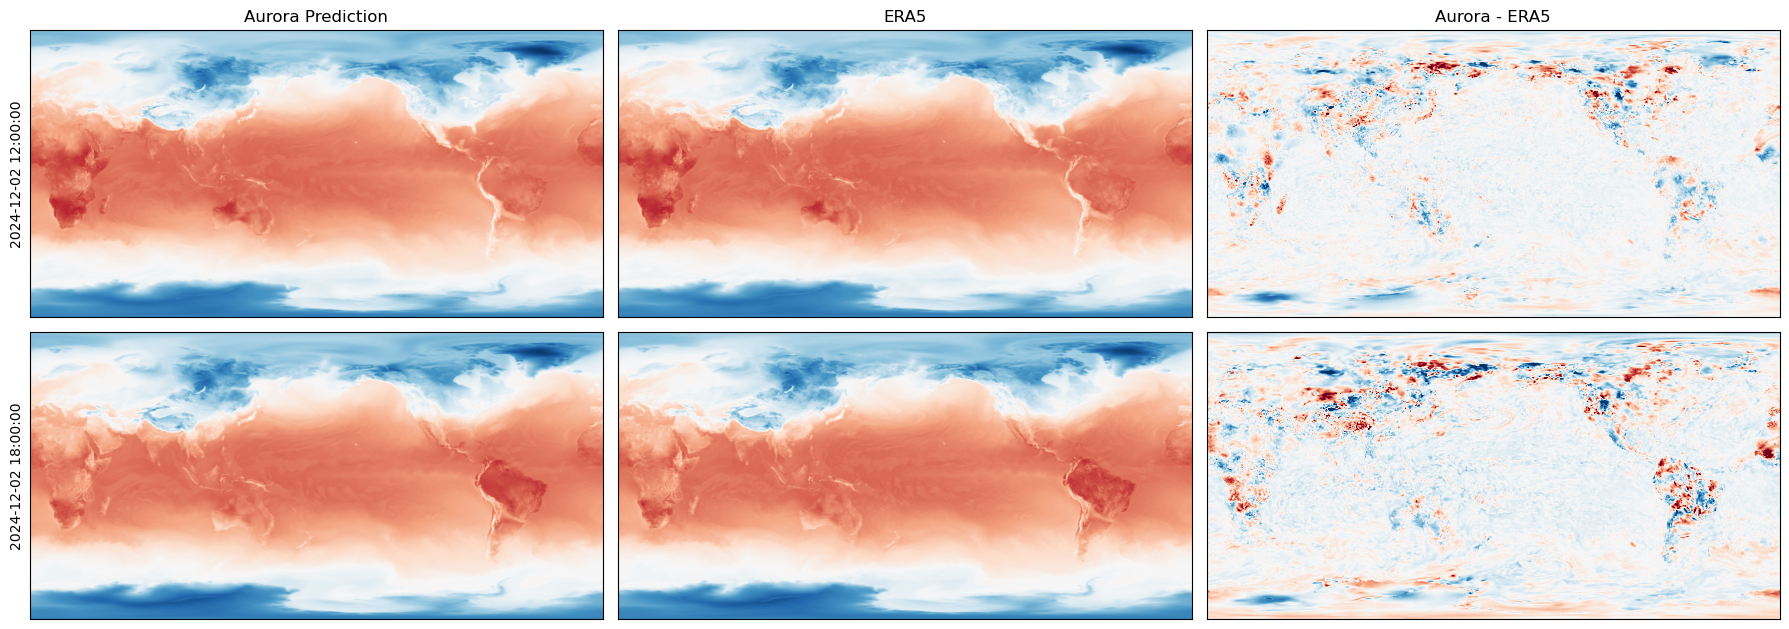

In [34]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(2, 3, figsize=(18, 6.5))

for i in range(ax.shape[0]):
    pred = preds[i]

    ax[i, 0].imshow(pred.surf_vars["2t"][0, 0].numpy() - 273.15, vmin=-50, vmax=50, cmap='RdBu_r')
    ax[i, 0].set_ylabel(str(pred.metadata.time[0]))
    if i == 0:
        ax[i, 0].set_title("Aurora Prediction")
    ax[i, 0].set_xticks([])
    ax[i, 0].set_yticks([])

    ax[i, 1].imshow(surf_vars_ds["t2m"][2 + i].values - 273.15, vmin=-50, vmax=50, cmap='RdBu_r')
    if i == 0:
        ax[i, 1].set_title("ERA5")
    ax[i, 1].set_xticks([])
    ax[i, 1].set_yticks([])
    
    ax[i, 2].imshow(pred.surf_vars["2t"][0, 0].numpy() - surf_vars_ds["t2m"][2 + i].values[:-1, :], vmin=-3, vmax=3, cmap='RdBu_r')
    if i == 0:
        ax[i, 2].set_title("Aurora - ERA5")
    ax[i, 2].set_xticks([])
    ax[i, 2].set_yticks([])    

plt.tight_layout()
